<a href="https://colab.research.google.com/github/norrismeg/odw/blob/main/Data_Challenge_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Challenge 2 (2 points) -- Rookie**

Signal in colored, Gaussian noise.

Use the data file challenge2.gwf, with channel name H1:CHALLENGE2.
The data contain a BBH signal with m1 = m2 = 30 solar masses, spin = 0.

1. What is the approximative time of the merger? (Hint: a plot of the q-transform could help)
2. Generate a time-domain template waveform using approximate SEOBNRv4_opt. with the same parameters as above. Plot this waveform.
3. Calculate a PSD of the data, and plot this on a log-log scale. Use axes ranging from 20 Hz up to the Nyquist frequency.
4. Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.
5. What is the matched filter SNR of the signal?

In [1]:
! pip install -q lalsuite
! pip install -q gwpy
! pip install -q pycbc
# -- Click "restart runtime" in the runtime menu

In [2]:
# -- download data
! wget https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf

# -- for gwpy
from gwpy.timeseries import TimeSeries
gwpy_strain = TimeSeries.read('challenge2.gwf', channel="H1:CHALLENGE2")

# -- for pycbc
from pycbc import frame
pycbc_strain = frame.read_frame('challenge2.gwf', 'H1:CHALLENGE2')

--2025-05-29 18:41:26--  https://dcc.ligo.org/public/0187/G2300818/001/challenge2.gwf
Resolving dcc.ligo.org (dcc.ligo.org)... 131.215.125.133
Connecting to dcc.ligo.org (dcc.ligo.org)|131.215.125.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4025853 (3.8M)
Saving to: ‘challenge2.gwf.1’

challenge2.gwf.1    100%[===================>]   3.84M  7.49MB/s    in 0.5s    

2025-05-29 18:41:27 (7.49 MB/s) - ‘challenge2.gwf.1’ saved [4025853/4025853]



/usr/local/lib/python3.11/dist-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


In [3]:
import numpy

import matplotlib.pyplot as plt

1. What is the approximative time of the merger? (Hint: a plot of the q-transform could help)

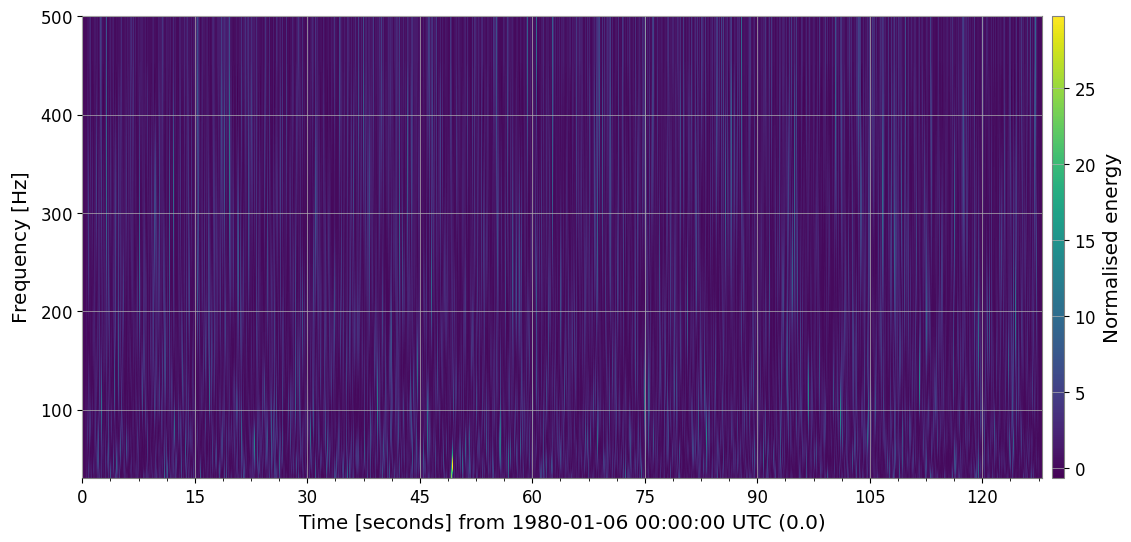

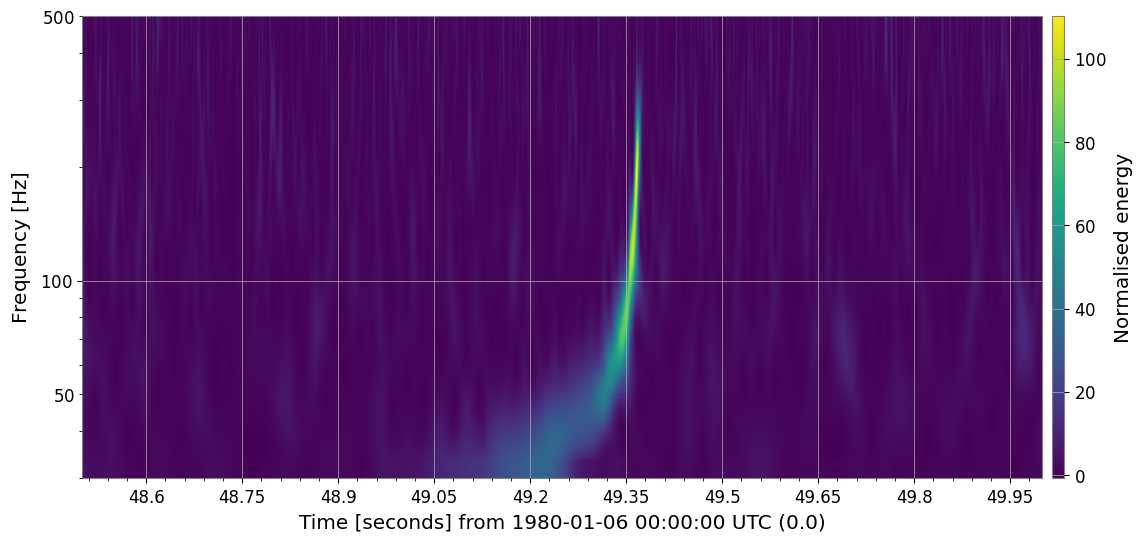

In [8]:
strain = gwpy_strain.q_transform(frange=(30,500), qrange=(4,12))
plot_q = strain.plot()
plot_q.colorbar(label="Normalised energy")

strain2 = gwpy_strain.q_transform(frange=(30, 500), outseg=(48.5,50),qrange=(4, 12))
plot_q2 = strain2.plot()
ax = plot_q2.gca()
ax.set_epoch(0)
ax.set_yscale('log')
ax.colorbar(label="Normalised energy")

2. Generate a time-domain template waveform using approximate SEOBNRv4_opt. with the same parameters as above. Plot this waveform.

3. Calculate a PSD of the data, and plot this on a log-log scale. Use axes ranging from 20 Hz up to the Nyquist frequency.

4. Use the template waveform and PSD to calculate the SNR time series. Plot the SNR time-series.

5. What is the matched filter SNR of the signal?